In [1]:
import numpy as np
import tensorflow as tf 
import sys 
import pathlib
import json 
import os
import matplotlib.pyplot as plt

os.chdir('/project/lhansen/Cap_NN_oldVersion/November_version_NewParameters/output/')
import version_Bin.model_pseudostate_original as model

In [3]:
###############################################################################
# 1. Define your export folder (trained model location) and parameters
###############################################################################
export_folder = "/project/lhansen/Cap_NN_oldVersion/November_version_NewParameters/output/Novem_NewParaters_0.01_LR_piecewiseconstant_10e-5,10e-5,10e-5,10e-5_128_neurons_32_#HiddenLayer_4_logxi_-3.0_logximax_5.0_num_iterations2000000"


batch_size                  =   128
num_iterations              = 2000000
logging_frequency           = 1000
learning_rates              = [10e-5, 10e-5, 10e-5, 10e-5]    # (10e-5 is 1e-4)
hidden_layer_activations    = ["swish","tanh","tanh","softplus"]
output_layer_activations    = ["softplus","custom","custom","softplus"]
num_hidden_layers           = 4
num_neurons                 = 32
learning_rate_schedule_type = "piecewiseconstant"
channel_type                = "full"
pretrained_path = None
tensorboard = True


## Take care of activation functions 
hidden_layer_activations   = [None if x == "None" else x for x in hidden_layer_activations]
output_layer_activations   = [None if x == "None" else x for x in output_layer_activations]


phi_g=16.7

v_nn_config   = {"num_hiddens" : [num_neurons for _ in range(num_hidden_layers)], "use_bias" : True, "activation" : hidden_layer_activations[0], "dim" : 1, "nn_name" : "v_nn"}
v_nn_config["final_activation"] = output_layer_activations[0]

i_g_nn_config = {"num_hiddens" : [num_neurons for _ in range(num_hidden_layers)], "use_bias" : True, "activation" : hidden_layer_activations[1], "dim" : 1, "nn_name" : "i_g_nn"}
i_g_nn_config["final_activation"] = lambda x: 1.0 - (1.0 + 1.0/ phi_g) / (tf.exp(2 * x) + 1.0)

i_d_nn_config = {"num_hiddens" : [num_neurons for _ in range(num_hidden_layers)], "use_bias" : True, "activation" : hidden_layer_activations[2], "dim" : 1, "nn_name" : "i_d_nn"}
i_d_nn_config["final_activation"] = lambda x: 1.0 - (1.0 + 1.0/ phi_g) / (tf.exp(2 * x) + 1.0)

i_I_nn_config = {"num_hiddens" : [num_neurons for _ in range(num_hidden_layers)], "use_bias" : True, "activation" : hidden_layer_activations[3], "dim" : 1, "nn_name" : "i_I_nn"}
i_I_nn_config["final_activation"] = output_layer_activations[3]


## Create params struct 
params_post_tech_post_damage = {"batch_size" : batch_size, "learning_rates":learning_rates,\
"v_nn_config" : v_nn_config, "i_g_nn_config" : i_g_nn_config, "i_d_nn_config" : i_d_nn_config,"i_I_nn_config":i_I_nn_config,\
"n_dims" : 3, "model_type" : "post_tech_post_damage" , \
"export_folder": export_folder +  "/post_tech_post_damage",
"num_iterations" : num_iterations, "logging_frequency": logging_frequency, "verbose": True, "load_parameters" : None,\
"pretrained_path" : pretrained_path, 'tensorboard' : tensorboard, "learning_rate_schedule_type" : learning_rate_schedule_type, "channel_type": channel_type }

 

params_post_tech_pre_damage = {"batch_size" : batch_size, "learning_rates":learning_rates,\
"v_nn_config" : v_nn_config, "i_g_nn_config" : i_g_nn_config, "i_d_nn_config" : i_d_nn_config,"i_I_nn_config":i_I_nn_config,\
"n_dims" : 3, "model_type" : "post_tech_pre_damage",
"export_folder": export_folder +  "/post_tech_pre_damage",
"v_post_tech_post_damage_nn_path": export_folder + "/post_tech_post_damage",                               
"num_iterations" : num_iterations, "logging_frequency": logging_frequency, "verbose": True, "load_parameters" : None,\
"pretrained_path" : pretrained_path, 'tensorboard' : tensorboard, "learning_rate_schedule_type" : learning_rate_schedule_type, "channel_type": channel_type }


params_pre_tech_post_damage = {"batch_size" : batch_size, "learning_rates":learning_rates,\
"v_nn_config" : v_nn_config, "i_g_nn_config" : i_g_nn_config, "i_d_nn_config" : i_d_nn_config,"i_I_nn_config":i_I_nn_config,\
"model_type":"pre_tech_post_damage",  "n_dims": 4,
"v_post_tech_post_damage_nn_path":  export_folder + "/post_tech_post_damage", "export_folder": export_folder +  "/pre_tech_post_damage",
"num_iterations" : num_iterations, "logging_frequency": logging_frequency, "verbose": True, "load_parameters" : None,\
"pretrained_path" : pretrained_path, 'tensorboard' : tensorboard, "learning_rate_schedule_type" : learning_rate_schedule_type, "channel_type": channel_type }


params_pre_tech_pre_damage = {"batch_size" : batch_size, "learning_rates":learning_rates,\
"v_nn_config" : v_nn_config, "i_g_nn_config" : i_g_nn_config, "i_d_nn_config" : i_d_nn_config,"i_I_nn_config":i_I_nn_config,\
"n_dims" : 4, "model_type" : "pre_tech_pre_damage" , \
"v_pre_tech_post_damage_nn_path": export_folder + "/pre_tech_post_damage" , 
"v_post_tech_pre_damage_nn_path": export_folder + "/post_tech_pre_damage",
"export_folder": export_folder +  "/pre_tech_pre_damage",
"num_iterations" : num_iterations, "logging_frequency": logging_frequency, "verbose": True, "load_parameters" : None,\
"pretrained_path" : pretrained_path, 'tensorboard' : tensorboard, "learning_rate_schedule_type" : learning_rate_schedule_type, "channel_type": channel_type }

 
# params["v_pre_tech_post_damage_nn_path"]  = export_folder + "/pre_tech_post_damage"  
# params["v_post_tech_pre_damage_nn_path"]  = export_folder + "/post_tech_pre_damage"
# params["export_folder"]  = export_folder +  "/pre_tech_pre_damage"

  
## i_g and i_d activations come after params because we amy want to use  


In [4]:
# Define the paths: Load all for paths for simulation
export_folder = "/project/lhansen/Cap_NN_oldVersion/November_version_NewParameters/output/Novem_NewParaters_0.01_LR_piecewiseconstant_10e-5,10e-5,10e-5,10e-5_128_neurons_32_#HiddenLayer_4_logxi_-3.0_logximax_5.0_num_iterations2000000"

v_nn_checkpoint_post_tech_post_damage_path = export_folder+  "/post_tech_post_damage"+'/v_nn_checkpoint_post_tech_post_damage'
i_g_nn_checkpoint_post_tech_post_damage_path = export_folder+  "/post_tech_post_damage"+'/i_g_nn_checkpoint_post_tech_post_damage'
i_d_nn_checkpoint_post_tech_post_damage_path = export_folder+  "/post_tech_post_damage"+'/i_d_nn_checkpoint_post_tech_post_damage' 

v_nn_checkpoint_post_tech_pre_damage_path = export_folder+  "/post_tech_pre_damage"+'/v_nn_checkpoint_post_tech_pre_damage'
i_g_nn_checkpoint_post_tech_pre_damage_path = export_folder+  "/post_tech_pre_damage"+'/i_g_nn_checkpoint_post_tech_pre_damage'
i_d_nn_checkpoint_post_tech_pre_damage_path = export_folder+  "/post_tech_pre_damage"+'/i_d_nn_checkpoint_post_tech_pre_damage' 

v_nn_checkpoint_pre_tech_post_damage_path = export_folder+  "/pre_tech_post_damage"+'/v_nn_checkpoint_pre_tech_post_damage'
i_g_nn_checkpoint_pre_tech_post_damage_path = export_folder+  "/pre_tech_post_damage"+'/i_g_nn_checkpoint_pre_tech_post_damage'
i_d_nn_checkpoint_pre_tech_post_damage_path = export_folder+  "/pre_tech_post_damage"+'/i_d_nn_checkpoint_pre_tech_post_damage' 
i_I_nn_checkpoint_pre_tech_post_damage_path = export_folder+  "/pre_tech_post_damage"+'/i_I_nn_checkpoint_pre_tech_post_damage' 

v_nn_checkpoint_pre_tech_pre_damage_path = export_folder+  "/pre_tech_pre_damage"+'/v_nn_checkpoint_pre_tech_pre_damage'
i_g_nn_checkpoint_pre_tech_pre_damage_path = export_folder+  "/pre_tech_pre_damage"+'/i_g_nn_checkpoint_pre_tech_pre_damage'
i_d_nn_checkpoint_pre_tech_pre_damage_path = export_folder+  "/pre_tech_pre_damage"+'/i_d_nn_checkpoint_pre_tech_pre_damage' 
i_I_nn_checkpoint_pre_tech_pre_damage_path = export_folder+  "/pre_tech_pre_damage"+'/i_I_nn_checkpoint_pre_tech_pre_damage' 

In [5]:

def load_model(params, n_inputs, v_nn_checkpoint_path, i_g_nn_checkpoint_path, i_d_nn_checkpoint_path,i_I_nn_checkpoint_path=None):
    test_model = model.model(params)
    
    # n_inputs = 7 # if "post_tech_post_damage" in params["model_type"] else 8
    test_model.v_nn.build((params["batch_size"], n_inputs))
    test_model.i_g_nn.build((params["batch_size"], n_inputs))
    test_model.i_d_nn.build((params["batch_size"], n_inputs)) 
    
    test_model.v_nn.load_weights(v_nn_checkpoint_path)
    test_model.i_g_nn.load_weights(i_g_nn_checkpoint_path)
    test_model.i_d_nn.load_weights(i_d_nn_checkpoint_path) 
    
    if i_I_nn_checkpoint_path is not None:
        test_model.i_I_nn.build((params["batch_size"], n_inputs)) 
        test_model.i_I_nn.load_weights(i_I_nn_checkpoint_path) 
    return test_model

In [6]:
 
post_tech_post_damage_model = load_model(params_post_tech_post_damage,7, v_nn_checkpoint_post_tech_post_damage_path, i_g_nn_checkpoint_post_tech_post_damage_path, i_d_nn_checkpoint_post_tech_post_damage_path)
 
post_tech_pre_damage_model = load_model(params_post_tech_pre_damage,6, v_nn_checkpoint_post_tech_pre_damage_path, i_g_nn_checkpoint_post_tech_pre_damage_path, i_d_nn_checkpoint_post_tech_pre_damage_path)


pre_tech_post_damage_model = load_model(params_pre_tech_post_damage,8, v_nn_checkpoint_pre_tech_post_damage_path, i_g_nn_checkpoint_pre_tech_post_damage_path, i_d_nn_checkpoint_pre_tech_post_damage_path, i_I_nn_checkpoint_pre_tech_post_damage_path)

pre_tech_pre_damage_model = load_model(params_pre_tech_pre_damage,7, v_nn_checkpoint_pre_tech_pre_damage_path, i_g_nn_checkpoint_pre_tech_pre_damage_path, i_d_nn_checkpoint_pre_tech_pre_damage_path, i_I_nn_checkpoint_pre_tech_pre_damage_path)

Tensorboard boolean = True
Tensorboard boolean = True
Tensorboard boolean = True
Pre tech model detected. Building a neural network for i_I
Tensorboard boolean = True
Pre tech model detected. Building a neural network for i_I


In [7]:
log_xi = tf.constant(-0.0, dtype=tf.float32) 

dt = 1/12
scale = tf.sqrt(dt)


def iterate_state(logK, R, Y, log_I_g,  A_g_prime, gamma_3, whether_Tech_jump, whether_Damage_jump):
    """
    Iterates the state variables to compute next period's state.
    
    Parameters:
        logK: Tensor or float representing the log capital stock.
        R: Tensor or float representing the rate/return.
        I_g: Tensor or float representing the log investment in technology.
        Y: Tensor or float representing the output.
        A_g_prime: Tensor or float representing the next state of the technology parameter.
        gamma_3: Tensor or float representing an additional state variable.
        whether_Tech_jump: Integer (0 or 1) indicating if a technology jump occurs.
        whether_Damage_jump: Integer (0 or 1) indicating if a damage jump occurs.
    
    Returns:
        next_logK, next_R, next_I_g, next_Y, next_A_g_prime, next_gamma_3:
        The updated state values.
    """
      
    ## Sampling the Weineer Processes
    increments = tf.random.normal(shape=[4], mean=0.0, stddev=1.0) * scale
    dW_g, dW_d, dW_Y, dW_log_I_g = tf.unstack(increments)
    
    
    
    sigma_K_d      = pre_tech_pre_damage_model.params["sigma_d"]* (1-R)
    sigma_K_g      = pre_tech_pre_damage_model.params["sigma_g"]* R

    sigma_R_d      = - pre_tech_pre_damage_model.params["sigma_d"]* R *(1-R)
    sigma_R_g      =   pre_tech_pre_damage_model.params["sigma_g"]* R *(1-R)

    sigma_I_g      =    pre_tech_pre_damage_model.params["sigma_I"]

    sigma_Y = pre_tech_pre_damage_model.params['varsigma'] *  pre_tech_pre_damage_model.params['eta'] * pre_tech_pre_damage_model.params['A_d'] * (1-R) * tf.exp(logK  )
        

    # Placeholder update rules for the (0,0) case: no jumps.
    if whether_Tech_jump == 0 and whether_Damage_jump == 0:
        
        model = pre_tech_pre_damage_model
        
      
        state_1d = tf.stack([
            tf.reshape(logK, []),
            tf.reshape(R, []),
            tf.reshape(Y, []),
            tf.reshape(log_I_g, []),
            tf.reshape(log_xi, []),
            tf.reshape(log_xi, []),
            tf.reshape(log_xi, [])
        ], axis=0)  # shape (7,)

        state = tf.reshape(state_1d, (1, 7))
        
        
        
        K=   tf.exp(logK  )
        
        ### Controls
        i_g        = model.i_g_nn(state)
        i_d        = model.i_d_nn(state)
        i_I        = model.i_I_nn(state)
            
        ### Increments
         
         
        v_kk_term = ( tf.pow(model.params["sigma_d"],2) * tf.pow(1-R,2)  + tf.pow(model.params["sigma_g"],2) * tf.pow(R,2))/2.0

        inside_log_i_d   =   tf.reshape( tf.math.maximum( 1 + model.params["phi_d"] * i_d , 0.0001), [1, 1])
        inside_log_i_g   =   tf.reshape( tf.math.maximum( 1 + model.params["phi_g"] * i_g , 0.0001), [1, 1])

        v_k_term       = ( model.params["alpha_d"] + model.params["Gamma"] * tf.math.log( inside_log_i_d ) ) * (1 - R) + ( model.params["alpha_g"] +  model.params["Gamma"] * tf.math.log( inside_log_i_g) ) * R  - v_kk_term
        
        v_r_term       = ( model.params["alpha_g"] + model.params["Gamma"] * tf.math.log( inside_log_i_g )  - (model.params["alpha_d"] + model.params["Gamma"] * tf.math.log( inside_log_i_d) ) + tf.pow(model.params["sigma_d"],2) *  (1-R ) - 
                        tf.pow(model.params["sigma_g"], 2) *  R ) *  R * (1 - R)
        
     
        v_y_term       = model.params["beta_f"] * (model.params["eta"] *  model.params["A_d"] * (1-R) * tf.exp(logK  ))

        
        v_I_g_term     = - model.params["zeta"] + model.params["psi_0"] * tf.exp(-i_I * model.params["psi_1"]) * tf.exp( model.params["psi_1"] * (logK -  log_I_g) ) - 0.5 * tf.pow(model.params["sigma_I"], 2)

    
        ## dW_K, dW_R, dW_Y, dW_log_I_g
        new_logK       = logK + v_k_term * dt +   sigma_K_d  * dW_d     +     sigma_K_g* dW_g
        
        new_R          = R + v_r_term * dt   +   sigma_R_d  * dW_d     +     sigma_R_g* dW_g
        
        new_log_I_g    = log_I_g + v_I_g_term * dt  + sigma_I_g * dW_log_I_g
        
        new_Y          = Y +  v_y_term * dt  + sigma_Y* dW_Y

        #### Sample Whether Jump
        I_d   = model.params['r_1'] * ( tf.exp( model.params['r_2'] / 2 * tf.pow(new_Y - model.params['y_lower_bar'],2) ) - 1  ) * \
            tf.cast(new_Y > model.params['y_lower_bar'], tf.float32 )
        
        p_jump = 1 - tf.exp(-I_d * dt)
        
        # Determine if a jump occurs
        jump_occur = tf.less(tf.random.uniform(shape=[], minval=0.0, maxval=1.0), p_jump)  # This is a boolean tensor
        # Update the whether jump indicator
        whether_Damage_jump+= tf.cast(jump_occur, tf.int32)
 
        gamma_3_list = np.linspace(model.params["gamma_3_min"], model.params["gamma_3_max"], model.params["gamma_3_length"]).tolist()
     
        # Convert gamma_3_list to a TensorFlow tensor for sampling
        gamma_3_tensor = tf.convert_to_tensor(gamma_3_list, dtype=tf.float32)
    
        # Sample an index uniformly among the gamma_3_list entries
        idx = tf.random.uniform(shape=[], minval=0, maxval=model.params["gamma_3_length"], dtype=tf.int32)
        sampled_val = gamma_3_tensor[idx]
    
        # If a jump occurs, use the sampled gamma_3 value; if not, return a default value (e.g., 0.0)
        gamma_3 = tf.cond(jump_occur, lambda: sampled_val, lambda: tf.constant(0.0))
        new_Y = tf.cond(jump_occur, lambda: tf.constant(2.0), lambda: new_Y)

        #### Tech jump
        I_tech = tf.exp(new_log_I_g) / model.params["varrho"]
        p_jump = 1 - tf.exp(-I_tech * dt)
         
        # Determine if a jump occurs
        jump_occur = tf.less(tf.random.uniform(shape=[], minval=0.0, maxval=1.0), p_jump)  # This is a boolean tensor
        # Update the whether jump indicator
        whether_Tech_jump+=  tf.cast(jump_occur, tf.int32)
           

        # Convert gamma_3_list to a TensorFlow tensor for sampling
        A_g_prime_tensor = tf.convert_to_tensor(model.params["A_g_prime_list"], dtype=tf.float32)
    
        # Sample an index uniformly among the gamma_3_list entries
        idx = tf.random.uniform(shape=[], minval=0, maxval=model.params["A_g_prime_length"], dtype=tf.int32)
        sampled_val = A_g_prime_tensor[idx]
    
        # If a jump occurs, use the sampled gamma_3 value; if not, return a default value (e.g., 0.0)
        A_g_prime = tf.cond(jump_occur, lambda: sampled_val, lambda: tf.constant(0.0))
        new_log_I_g = tf.cond(jump_occur, lambda: tf.constant(0.0), lambda: new_log_I_g)
        
        
    # Placeholder update rules for the (0,1) case: damage jump only.
    elif whether_Tech_jump == 0 and whether_Damage_jump == 1:

        
        model = pre_tech_post_damage_model        
        
   
        
        state_1d = tf.stack([
            tf.reshape(logK, []),
            tf.reshape(R, []),
            tf.reshape(Y, []),
            tf.reshape(log_I_g, []),
             tf.reshape(gamma_3, []),
            tf.reshape(log_xi, []),
            tf.reshape(log_xi, []),
            tf.reshape(log_xi, [])
        ], axis=0)   

        state = tf.reshape(state_1d, (1, 8))
        
        
        K=   tf.exp(logK  )
        
        ### Controls
        i_g        = model.i_g_nn(state)
        i_d        = model.i_d_nn(state)
        i_I        = model.i_I_nn(state)
            
        ### Increments
         
 
        
        v_kk_term = ( tf.pow(model.params["sigma_d"],2) * tf.pow(1-R,2)  + tf.pow(model.params["sigma_g"],2) * tf.pow(R,2))/2.0

        inside_log_i_d   =   tf.reshape( tf.math.maximum( 1 + model.params["phi_d"] * i_d , 0.0001), [1, 1])
        inside_log_i_g   =   tf.reshape( tf.math.maximum( 1 + model.params["phi_g"] * i_g , 0.0001), [1, 1])

        v_k_term       = ( model.params["alpha_d"] + model.params["Gamma"] * tf.math.log( inside_log_i_d ) ) * (1 - R) + ( model.params["alpha_g"] +  model.params["Gamma"] * tf.math.log( inside_log_i_g) ) * R  - v_kk_term
        
        v_r_term       = ( model.params["alpha_g"] + model.params["Gamma"] * tf.math.log( inside_log_i_g )  - (model.params["alpha_d"] + model.params["Gamma"] * tf.math.log( inside_log_i_d) ) + tf.pow(model.params["sigma_d"],2) *  (1-R ) - 
                        tf.pow(model.params["sigma_g"], 2) *  R ) *  R * (1 - R)
        
     
        v_y_term       = model.params["beta_f"] * (model.params["eta"] *  model.params["A_d"] * (1-R) * tf.exp(logK  ))

        
        v_I_g_term     = - model.params["zeta"] + model.params["psi_0"] * tf.exp(-i_I * model.params["psi_1"]) * tf.exp( model.params["psi_1"] * (logK -  log_I_g) ) - 0.5 * tf.pow(model.params["sigma_I"], 2)

    
        ## dW_K, dW_R, dW_Y, dW_log_I_g
        new_logK       = logK + v_k_term * dt +   sigma_K_d  * dW_d     +     sigma_K_g* dW_g
        
        new_R          = R + v_r_term * dt   +   sigma_R_d  * dW_d     +     sigma_R_g* dW_g
        
        new_log_I_g    = log_I_g + v_I_g_term * dt  + sigma_I_g * dW_log_I_g
        
        new_Y          = Y +  v_y_term * dt  + sigma_Y* dW_Y


        #### Tech jump
        I_tech = tf.exp(new_log_I_g) / model.params["varrho"]
        p_jump = 1 - tf.exp(-I_tech * dt)
         
        # Determine if a jump occurs
        jump_occur = tf.less(tf.random.uniform(shape=[], minval=0.0, maxval=1.0), p_jump)  # This is a boolean tensor
        # Update the whether jump indicator
        whether_Tech_jump+= tf.cast(jump_occur, tf.int32)
  
        # Convert gamma_3_list to a TensorFlow tensor for sampling
        A_g_prime_tensor = tf.convert_to_tensor(model.params["A_g_prime_list"], dtype=tf.float32)
    
        # Sample an index uniformly among the gamma_3_list entries
        idx = tf.random.uniform(shape=[], minval=0, maxval=model.params["A_g_prime_length"], dtype=tf.int32)
        sampled_val = A_g_prime_tensor[idx]
    
        # If a jump occurs, use the sampled gamma_3 value; if not, return a default value (e.g., 0.0)
        A_g_prime = tf.cond(jump_occur, lambda: sampled_val, lambda: tf.constant(0.0))
        new_log_I_g = tf.cond(jump_occur, lambda: tf.constant(0.0), lambda: new_log_I_g)
        
        
    # Placeholder update rules for the (1,0) case: technology jump only.
    elif whether_Tech_jump == 1 and whether_Damage_jump == 0:
        model = post_tech_pre_damage_model        
          
        state_1d = tf.stack([
            tf.reshape(logK, []),
            tf.reshape(R, []),
            tf.reshape(Y, []), 
             tf.reshape(A_g_prime, []),
            tf.reshape(log_xi, []),
            tf.reshape(log_xi, []) 
        ], axis=0)   
        
        state    = tf.reshape(state_1d, (1,6))
        
        K=   tf.exp(logK  )
        
        ### Controls
        i_g        = model.i_g_nn(state)
        i_d        = model.i_d_nn(state)
        
        
        
         
        v_kk_term = ( tf.pow(model.params["sigma_d"],2) * tf.pow(1-R,2)  + tf.pow(model.params["sigma_g"],2) * tf.pow(R,2))/2.0

        inside_log_i_d   =   tf.reshape( tf.math.maximum( 1 + model.params["phi_d"] * i_d , 0.0001), [1, 1])
        inside_log_i_g   =   tf.reshape( tf.math.maximum( 1 + model.params["phi_g"] * i_g , 0.0001), [1, 1])

        v_k_term       = ( model.params["alpha_d"] + model.params["Gamma"] * tf.math.log( inside_log_i_d ) ) * (1 - R) + ( model.params["alpha_g"] +  model.params["Gamma"] * tf.math.log( inside_log_i_g) ) * R  - v_kk_term
        
        v_r_term       = ( model.params["alpha_g"] + model.params["Gamma"] * tf.math.log( inside_log_i_g )  - (model.params["alpha_d"] + model.params["Gamma"] * tf.math.log( inside_log_i_d) ) + tf.pow(model.params["sigma_d"],2) *  (1-R ) - 
                        tf.pow(model.params["sigma_g"], 2) *  R ) *  R * (1 - R)
        
     
        v_y_term       = model.params["beta_f"] * (model.params["eta"] *  model.params["A_d"] * (1-R) * tf.exp(logK  ))

        
      
    
        ## dW_K, dW_R, dW_Y, dW_log_I_g
        new_logK       = logK + v_k_term * dt +   sigma_K_d  * dW_d     +     sigma_K_g* dW_g
        
        new_R          = R + v_r_term * dt   +   sigma_R_d  * dW_d     +     sigma_R_g* dW_g
        
        new_log_I_g    = tf.constant(0.0)
        
        new_Y          = Y +  v_y_term * dt  + sigma_Y* dW_Y

        #### Sample Whether Jump
        I_d   = model.params['r_1'] * ( tf.exp( model.params['r_2'] / 2 * tf.pow(new_Y - model.params['y_lower_bar'],2) ) - 1  ) * \
            tf.cast(new_Y > model.params['y_lower_bar'], tf.float32 )
        
        p_jump = 1 - tf.exp(-I_d * dt)
        
        # Determine if a jump occurs
        jump_occur = tf.less(tf.random.uniform(shape=[], minval=0.0, maxval=1.0), p_jump)  # This is a boolean tensor
        # Update the whether jump indicator
        whether_Damage_jump+=tf.cast(jump_occur, tf.int32) 
 
        gamma_3_list = np.linspace(model.params["gamma_3_min"], model.params["gamma_3_max"], model.params["gamma_3_length"]).tolist()
     
        # Convert gamma_3_list to a TensorFlow tensor for sampling
        gamma_3_tensor = tf.convert_to_tensor(gamma_3_list, dtype=tf.float32)
    
        # Sample an index uniformly among the gamma_3_list entries
        idx = tf.random.uniform(shape=[], minval=0, maxval=model.params["gamma_3_length"], dtype=tf.int32)
        sampled_val = gamma_3_tensor[idx]
    
        # If a jump occurs, use the sampled gamma_3 value; if not, return a default value (e.g., 0.0)
        gamma_3 = tf.cond(jump_occur, lambda: sampled_val, lambda: tf.constant(0.0))
        new_Y = tf.cond(jump_occur, lambda: tf.constant(2.0), lambda: new_Y)
   
            
    # Placeholder update rules for the (1,1) case: both technology and damage jump.
    elif whether_Tech_jump == 1 and whether_Damage_jump == 1:
        model = post_tech_post_damage_model        
 
        
        state_1d = tf.stack([
            tf.reshape(logK, []),
            tf.reshape(R, []),
            tf.reshape(Y, []),
            tf.reshape(gamma_3, []),
            tf.reshape(A_g_prime, []),
            tf.reshape(log_xi, []),
            tf.reshape(log_xi, [])
        ], axis=0)   

        state = tf.reshape(state_1d, (1, 7))
        
        ### Controls
        i_g        = model.i_g_nn(state)
        i_d        = model.i_d_nn(state)
         
        v_kk_term = ( tf.pow(model.params["sigma_d"],2) * tf.pow(1-R,2)  + tf.pow(model.params["sigma_g"],2) * tf.pow(R,2))/2.0

        inside_log_i_d   =   tf.reshape( tf.math.maximum( 1 + model.params["phi_d"] * i_d , 0.0001), [1, 1])
        inside_log_i_g   =   tf.reshape( tf.math.maximum( 1 + model.params["phi_g"] * i_g , 0.0001), [1, 1])

        v_k_term       = ( model.params["alpha_d"] + model.params["Gamma"] * tf.math.log( inside_log_i_d ) ) * (1 - R) + ( model.params["alpha_g"] +  model.params["Gamma"] * tf.math.log( inside_log_i_g) ) * R  - v_kk_term
        
        v_r_term       = ( model.params["alpha_g"] + model.params["Gamma"] * tf.math.log( inside_log_i_g )  - (model.params["alpha_d"] + model.params["Gamma"] * tf.math.log( inside_log_i_d) ) + tf.pow(model.params["sigma_d"],2) *  (1-R ) - 
                        tf.pow(model.params["sigma_g"], 2) *  R ) *  R * (1 - R)
        
     
        v_y_term       = model.params["beta_f"] * (model.params["eta"] *  model.params["A_d"] * (1-R) * tf.exp(logK  ))

        
      
    
        ## dW_K, dW_R, dW_Y, dW_log_I_g
        new_logK       = logK + v_k_term * dt +   sigma_K_d  * dW_d     +     sigma_K_g* dW_g
        
        new_R          = R + v_r_term * dt   +   sigma_R_d  * dW_d     +     sigma_R_g* dW_g
        
        new_log_I_g    = tf.constant(0.0)
        
        new_Y          = Y +  v_y_term * dt  + sigma_Y* dW_Y
        
    else:
        raise ValueError("Invalid jump condition values. They should be either 0 or 1.")

    return new_logK, new_R, new_log_I_g, new_Y, A_g_prime, gamma_3, whether_Tech_jump, whether_Damage_jump

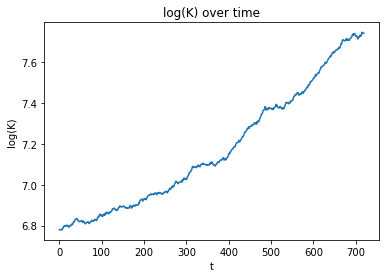

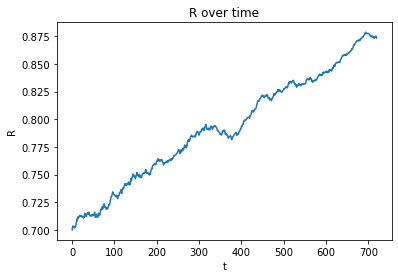

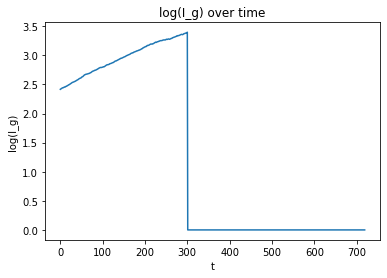

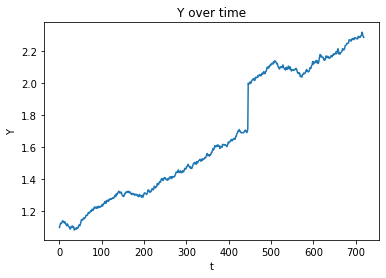

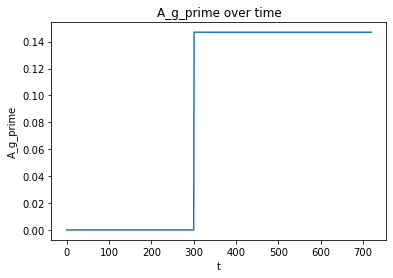

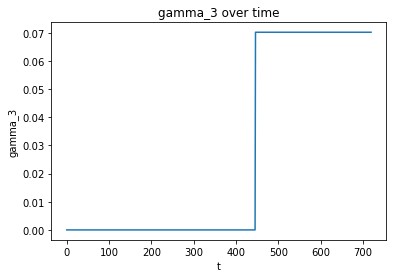

In [9]:
# Ensure your 'iterate_state' is defined as above or in the same file

# Set up initial conditions
init_logK     = tf.math.log(880.0)   # shape []
init_R        = tf.constant(0.7, dtype=tf.float32)
init_log_I_g  = tf.math.log(11.2)
init_Y        = tf.constant(1.1, dtype=tf.float32)
init_A_g_prime= tf.constant(0.0, dtype=tf.float32)
init_gamma_3  = tf.constant(0.0, dtype=tf.float32)
init_TechJump = tf.constant(0, dtype=tf.int32)
init_DmgJump  = tf.constant(0, dtype=tf.int32)

T = 720  # number of time steps

# Lists to store the simulation path
logK_path        = []
R_path           = []
log_I_g_path     = []
Y_path           = []
A_g_prime_path   = []
gamma_3_path     = []
tech_jump_path   = []
damage_jump_path = []

# Current (starting) state
logK_t     = init_logK
R_t        = init_R
log_I_g_t  = init_log_I_g
Y_t        = init_Y
A_g_prime_t= init_A_g_prime
gamma_3_t  = init_gamma_3
tech_jump_t= init_TechJump
dmg_jump_t = init_DmgJump

for t in range(T):
    # Record
    logK_path.append(float(logK_t.numpy()))
    R_path.append(float(R_t.numpy()))
    log_I_g_path.append(float(log_I_g_t.numpy()))
    Y_path.append(float(Y_t.numpy()))
    A_g_prime_path.append(float(A_g_prime_t.numpy()))
    gamma_3_path.append(float(gamma_3_t.numpy()))
    tech_jump_path.append(int(tech_jump_t.numpy()))
    damage_jump_path.append(int(dmg_jump_t.numpy()))


    # Step forward
    (logK_t,
     R_t,
     log_I_g_t,
     Y_t,
     A_g_prime_t,
     gamma_3_t,
     tech_jump_t,
     dmg_jump_t) = iterate_state(
        logK_t,
        R_t,
        Y_t,
        log_I_g_t,
        A_g_prime_t,
        gamma_3_t,
        tech_jump_t,
        dmg_jump_t
    )

# Convert to numpy arrays for plotting
logK_path = np.array(logK_path)
R_path = np.array(R_path)
log_I_g_path = np.array(log_I_g_path)
Y_path = np.array(Y_path)
A_g_prime_path = np.array(A_g_prime_path)
gamma_3_path = np.array(gamma_3_path)
tech_jump_path = np.array(tech_jump_path)
damage_jump_path = np.array(damage_jump_path)

# Plot each state in its own figure
plt.plot(logK_path)
plt.title("log(K) over time")
plt.xlabel("t")
plt.ylabel("log(K)")
plt.show()

plt.plot(R_path)
plt.title("R over time")
plt.xlabel("t")
plt.ylabel("R")
plt.show()

plt.plot(log_I_g_path)
plt.title("log(I_g) over time")
plt.xlabel("t")
plt.ylabel("log(I_g)")
plt.show()

plt.plot(Y_path)
plt.title("Y over time")
plt.xlabel("t")
plt.ylabel("Y")
plt.show()

plt.plot(A_g_prime_path)
plt.title("A_g_prime over time")
plt.xlabel("t")
plt.ylabel("A_g_prime")
plt.show()

plt.plot(gamma_3_path)
plt.title("gamma_3 over time")
plt.xlabel("t")
plt.ylabel("gamma_3")
plt.show()
 

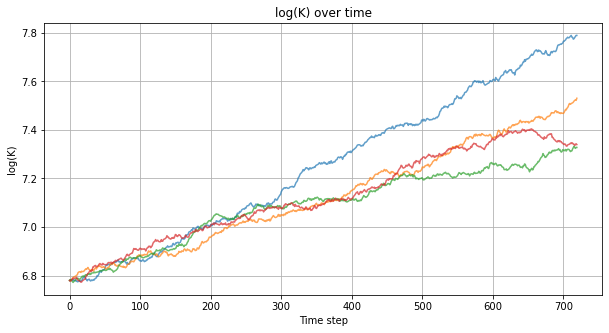

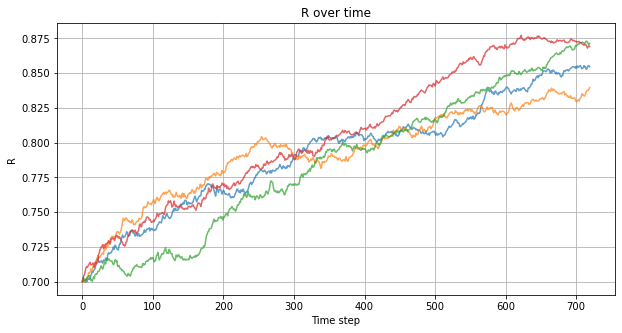

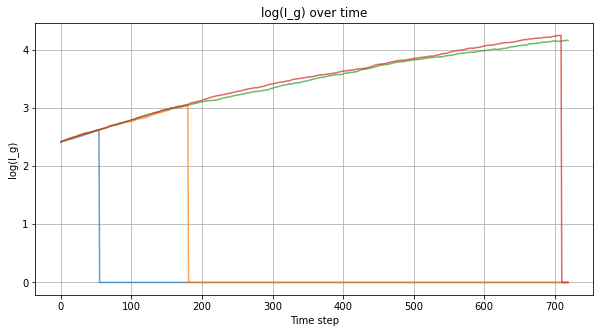

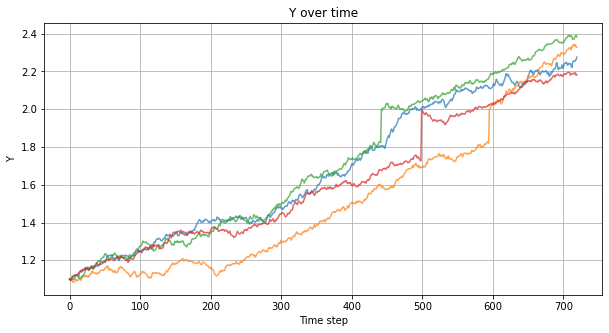

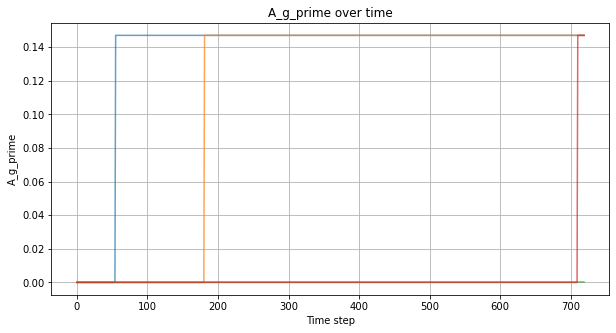

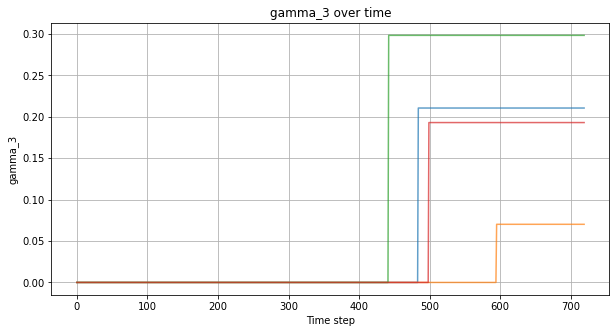

In [14]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# --- Simulation parameters ---
T = 720           # number of time steps
n_paths = 4      # number of simulations

# --- Initial state ---
init_logK      = tf.math.log(880.0)
init_R         = tf.constant(0.7, dtype=tf.float32)
init_log_I_g   = tf.math.log(11.2)
init_Y         = tf.constant(1.1, dtype=tf.float32)
init_A_g_prime = tf.constant(0.0, dtype=tf.float32)
init_gamma_3   = tf.constant(0.0, dtype=tf.float32)
init_TechJump  = tf.constant(0, dtype=tf.int32)
init_DmgJump   = tf.constant(0, dtype=tf.int32)

# --- Containers for all paths (each will be [n_paths, T]) ---
logK_paths        = np.zeros((n_paths, T))
R_paths           = np.zeros((n_paths, T))
log_I_g_paths     = np.zeros((n_paths, T))
Y_paths           = np.zeros((n_paths, T))
A_g_prime_paths   = np.zeros((n_paths, T))
gamma_3_paths     = np.zeros((n_paths, T))
tech_jump_paths   = np.zeros((n_paths, T))
damage_jump_paths = np.zeros((n_paths, T))

# --- Outer loop for each path ---
for path_id in range(n_paths):
    # Reset state at start of each path
    logK_t      = init_logK
    R_t         = init_R
    log_I_g_t   = init_log_I_g
    Y_t         = init_Y
    A_g_prime_t = init_A_g_prime
    gamma_3_t   = init_gamma_3
    tech_jump_t = init_TechJump
    dmg_jump_t  = init_DmgJump

    for t in range(T):
        # Record
        logK_paths[path_id, t]        = float(logK_t.numpy())
        R_paths[path_id, t]           = float(R_t.numpy())
        log_I_g_paths[path_id, t]     = float(log_I_g_t.numpy())
        Y_paths[path_id, t]           = float(Y_t.numpy())
        A_g_prime_paths[path_id, t]   = float(A_g_prime_t.numpy())
        gamma_3_paths[path_id, t]     = float(gamma_3_t.numpy())
        tech_jump_paths[path_id, t]   = int(tech_jump_t.numpy())
        damage_jump_paths[path_id, t] = int(dmg_jump_t.numpy())

        # Simulate forward one step
        (logK_t,
         R_t,
         log_I_g_t,
         Y_t,
         A_g_prime_t,
         gamma_3_t,
         tech_jump_t,
         dmg_jump_t) = iterate_state(
            logK_t,
            R_t,
            Y_t,
            log_I_g_t,
            A_g_prime_t,
            gamma_3_t,
            tech_jump_t,
            dmg_jump_t
        )

# --- Plotting ---
time = np.arange(T)

def plot_all_paths(data, title, ylabel):
    plt.figure(figsize=(10, 5))
    for i in range(n_paths):
        plt.plot(time, data[i], label=f'Path {i+1}', alpha=0.7)
    plt.title(title)
    plt.xlabel("Time step")
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()

plot_all_paths(logK_paths,        "log(K) over time",         "log(K)")
plot_all_paths(R_paths,           "R over time",              "R")
plot_all_paths(log_I_g_paths,     "log(I_g) over time",       "log(I_g)")
plot_all_paths(Y_paths,           "Y over time",              "Y")
plot_all_paths(A_g_prime_paths,   "A_g_prime over time",      "A_g_prime")
plot_all_paths(gamma_3_paths,     "gamma_3 over time",        "gamma_3") 


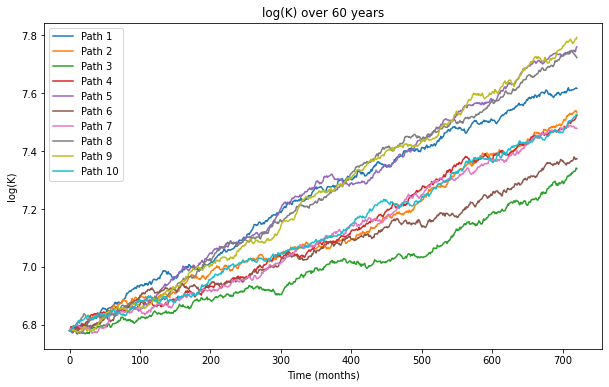

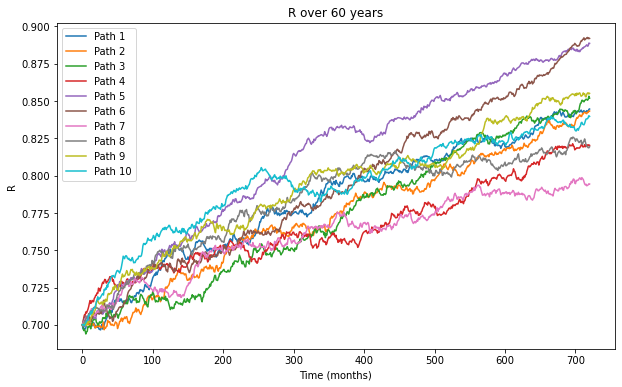

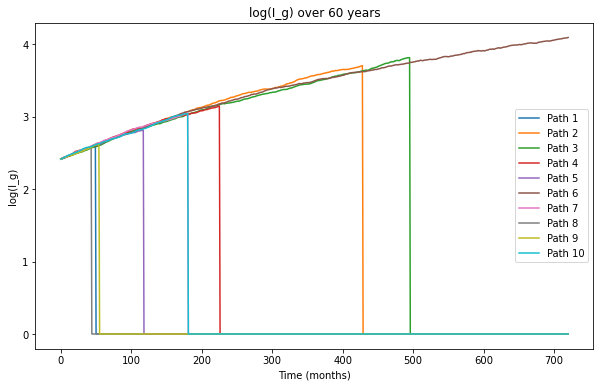

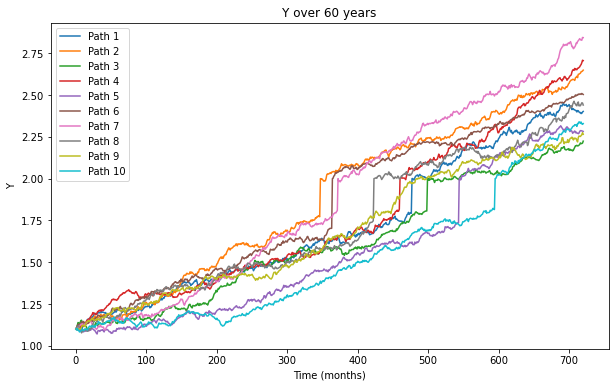

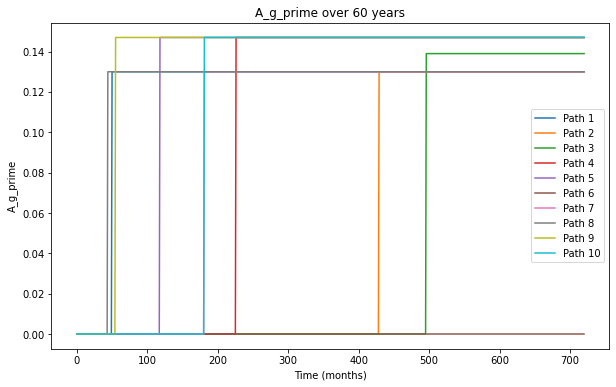

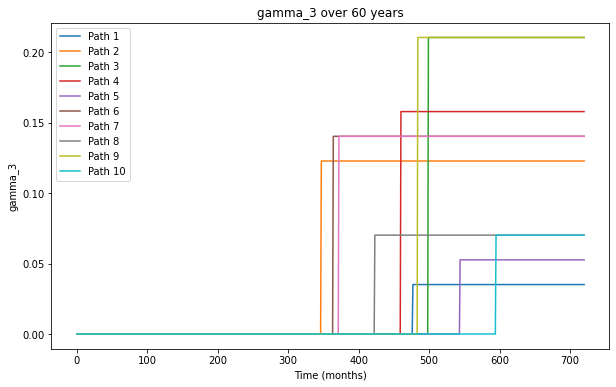

In [10]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# --- Simulation parameters ---
dt = 1/12                   # one month per time step
scale = tf.sqrt(dt)         # scale for the Wiener increments
T = 60 * 12                 # total time steps for 60 years (720 steps)
n_paths = 10                # number of simulation paths

# --- Initial values ---
init_logK     = tf.math.log(880.0)              # log capital stock
init_R        = tf.constant(0.7, dtype=tf.float32)
init_log_I_g  = tf.math.log(11.2)
init_Y        = tf.constant(1.1, dtype=tf.float32)
init_A_g_prime= tf.constant(0.0, dtype=tf.float32)
init_gamma_3  = tf.constant(0.0, dtype=tf.float32)
init_TechJump = tf.constant(0, dtype=tf.int32)
init_DmgJump  = tf.constant(0, dtype=tf.int32)

# Define log_xi (used in iterate_state)
log_xi = tf.constant(-1.0, dtype=tf.float32)

# --- Simulation storage lists ---
logK_sim        = []
R_sim           = []
log_I_g_sim     = []
Y_sim           = []
A_g_prime_sim   = []
gamma_3_sim     = []
tech_jump_sim   = []
damage_jump_sim = []

# --- Simulation loop over n_paths ---
for sim in range(n_paths):
    # Initialize the current state values for the simulation path
    logK_t      = init_logK
    R_t         = init_R
    log_I_g_t   = init_log_I_g
    Y_t         = init_Y
    A_g_prime_t = init_A_g_prime
    gamma_3_t   = init_gamma_3
    tech_jump_t = init_TechJump
    dmg_jump_t  = init_DmgJump
    
    # Lists to store the simulation path for each variable
    logK_path      = []
    R_path         = []
    log_I_g_path   = []
    Y_path         = []
    A_g_prime_path = []
    gamma_3_path   = []
    tech_jump_path = []
    damage_jump_path = []
    
    # Record the initial state (convert tensors to scalars)
    logK_path.append(float(logK_t.numpy()))
    R_path.append(float(R_t.numpy()))
    log_I_g_path.append(float(log_I_g_t.numpy()))
    Y_path.append(float(Y_t.numpy()))
    A_g_prime_path.append(float(A_g_prime_t.numpy()))
    gamma_3_path.append(float(gamma_3_t.numpy()))
    tech_jump_path.append(int(tech_jump_t.numpy()))
    damage_jump_path.append(int(dmg_jump_t.numpy()))
    
    # Run simulation for T time steps
    for t in range(T):
        (logK_t,
         R_t,
         log_I_g_t,
         Y_t,
         A_g_prime_t,
         gamma_3_t,
         tech_jump_t,
         dmg_jump_t) = iterate_state(
                          logK_t,
                          R_t,
                          Y_t,
                          log_I_g_t,
                          A_g_prime_t,
                          gamma_3_t,
                          tech_jump_t,
                          dmg_jump_t)
                          
        # Record state variables at the current time step
        logK_path.append(float(logK_t.numpy()))
        R_path.append(float(R_t.numpy()))
        log_I_g_path.append(float(log_I_g_t.numpy()))
        Y_path.append(float(Y_t.numpy()))
        A_g_prime_path.append(float(A_g_prime_t.numpy()))
        gamma_3_path.append(float(gamma_3_t.numpy()))
        tech_jump_path.append(int(tech_jump_t.numpy()))
        damage_jump_path.append(int(dmg_jump_t.numpy()))
    
    # Convert the lists to NumPy arrays (with uniform scalar entries)
    logK_sim.append(np.array(logK_path, dtype=float))
    R_sim.append(np.array(R_path, dtype=float))
    log_I_g_sim.append(np.array(log_I_g_path, dtype=float))
    Y_sim.append(np.array(Y_path, dtype=float))
    A_g_prime_sim.append(np.array(A_g_prime_path, dtype=float))
    gamma_3_sim.append(np.array(gamma_3_path, dtype=float))
    tech_jump_sim.append(np.array(tech_jump_path, dtype=int))
    damage_jump_sim.append(np.array(damage_jump_path, dtype=int))

# --- Plotting the simulation results ---
time_axis = np.arange(T + 1)  # time axis in months (includes the initial state)

# Plot log(K)
plt.figure(figsize=(10, 6))
for i in range(n_paths):
    plt.plot(time_axis, logK_sim[i], label=f'Path {i+1}')
plt.title('log(K) over 60 years')
plt.xlabel('Time (months)')
plt.ylabel('log(K)')
plt.legend()
plt.show()

# Plot R
plt.figure(figsize=(10, 6))
for i in range(n_paths):
    plt.plot(time_axis, R_sim[i], label=f'Path {i+1}')
plt.title('R over 60 years')
plt.xlabel('Time (months)')
plt.ylabel('R')
plt.legend()
plt.show()

# Plot log(I_g)
plt.figure(figsize=(10, 6))
for i in range(n_paths):
    plt.plot(time_axis, log_I_g_sim[i], label=f'Path {i+1}')
plt.title('log(I_g) over 60 years')
plt.xlabel('Time (months)')
plt.ylabel('log(I_g)')
plt.legend()
plt.show()

# Plot Y
plt.figure(figsize=(10, 6))
for i in range(n_paths):
    plt.plot(time_axis, Y_sim[i], label=f'Path {i+1}')
plt.title('Y over 60 years')
plt.xlabel('Time (months)')
plt.ylabel('Y')
plt.legend()
plt.show()

# Plot A_g_prime
plt.figure(figsize=(10, 6))
for i in range(n_paths):
    plt.plot(time_axis, A_g_prime_sim[i], label=f'Path {i+1}')
plt.title('A_g_prime over 60 years')
plt.xlabel('Time (months)')
plt.ylabel('A_g_prime')
plt.legend()
plt.show()

# Plot gamma_3
plt.figure(figsize=(10, 6))
for i in range(n_paths):
    plt.plot(time_axis, gamma_3_sim[i], label=f'Path {i+1}')
plt.title('gamma_3 over 60 years')
plt.xlabel('Time (months)')
plt.ylabel('gamma_3')
plt.legend()
plt.show()




Processing variable: logK


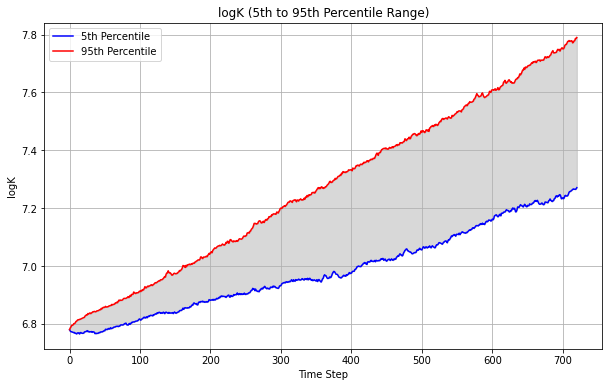

Processing variable: Z


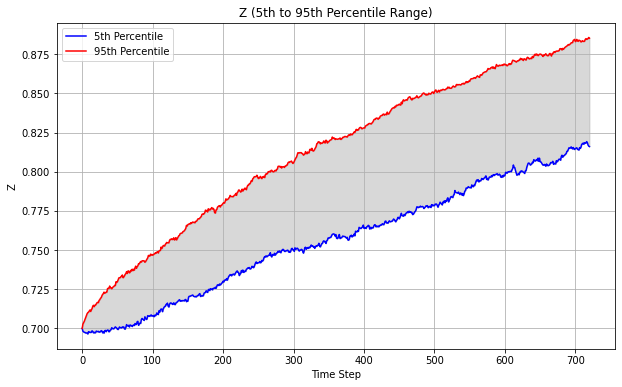

Processing variable: log_R


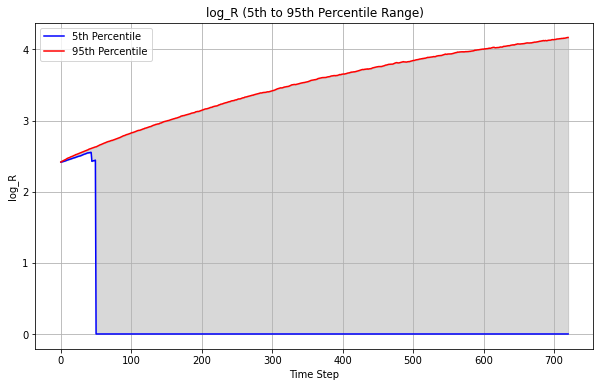

Processing variable: Y


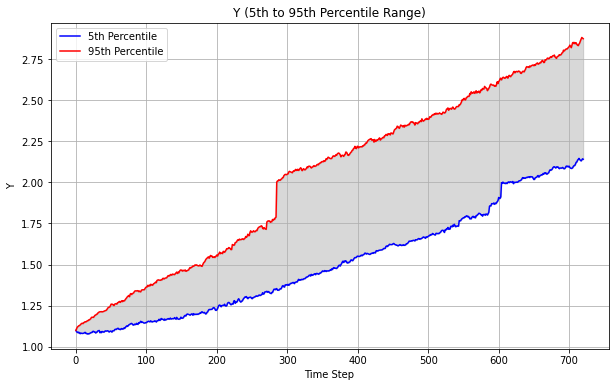

In [1]:
# Import required libraries
import os
import numpy as np
import matplotlib.pyplot as plt

# Folder where the simulation results are stored.
data_folder = '/project/lhansen/Cap_NN_oldVersion/November_version_NewParameters/Simulation/paths#100'

# Dictionary to map a variable label (for plotting) to the prefix used in file names.
# Adjust the keys and prefixes if needed.
variables = {
    'logK':   'logK_sim',      # files like logK_sim_1.npy, logK_sim_2.npy, ...
    'Z':      'R_array',       # files like R_array_1.npy, R_array_2.npy, ...
    'log_R': 'log_I_g_array', # files like log_I_g_array_1.npy, log_I_g_array_2.npy, ...
    'Y':      'Y_array'        # files like Y_array_1.npy, Y_array_2.npy, ...
}

def load_and_concatenate(folder, prefix):
    """
    Loads all .npy files in the given folder that start with the specified prefix.
    Each file is assumed to be a 2D NumPy array of shape (paths_per_file, time_steps).
    Concatenates them along the first axis so that all simulation paths from all files are merged.
    
    Parameters:
        folder (str): The directory path where the files are stored.
        prefix (str): The file name prefix, e.g. 'log_I_g_array'.
        
    Returns:
        np.ndarray: A 2D NumPy array with shape (total_paths, time_steps). 
        If no files are found, returns None.
    """
    files = []
    for fname in os.listdir(folder):
        if fname.startswith(prefix) and fname.endswith('.npy'):
            files.append(os.path.join(folder, fname))
    if not files:
        print(f"No files found for prefix '{prefix}' in folder '{folder}'")
        return None
    # Sort files to have a consistent ordering (assumes naming scheme like prefix_1.npy, prefix_2.npy, ...)
    files = sorted(files)
    
    data_list = []
    for f in files:
        data = np.load(f)
        # data is assumed to be 2D: (paths_per_file, time_steps)
        data_list.append(data)
    # Concatenate along the 0th axis to combine all paths into one array.
    return np.concatenate(data_list, axis=0)

# Loop over each variable, load the data, compute the percentiles, and plot.
for var_label, prefix in variables.items():
    print(f"Processing variable: {var_label}")
    data = load_and_concatenate(data_folder, prefix)
    if data is None:
        continue
    
    # data: shape (total_paths, time_steps)
    # Compute the 5th and 95th percentiles at each time step (over all paths).
    lower_percentile = np.percentile(data, 5, axis=0)
    upper_percentile = np.percentile(data, 95, axis=0)
    
    # Create a time vector assuming time is along the columns.
    time_steps = np.arange(data.shape[1])
    
    # Plot the percentile bands.
    plt.figure(figsize=(10, 6))
    plt.plot(time_steps, lower_percentile, label='5th Percentile', color='blue')
    plt.plot(time_steps, upper_percentile, label='95th Percentile', color='red')
    plt.fill_between(time_steps, lower_percentile, upper_percentile, color='gray', alpha=0.3)
    plt.xlabel('Time Step')
    plt.ylabel(var_label)
    plt.title(f'{var_label} (5th to 95th Percentile Range)')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()


Processing variable: logK


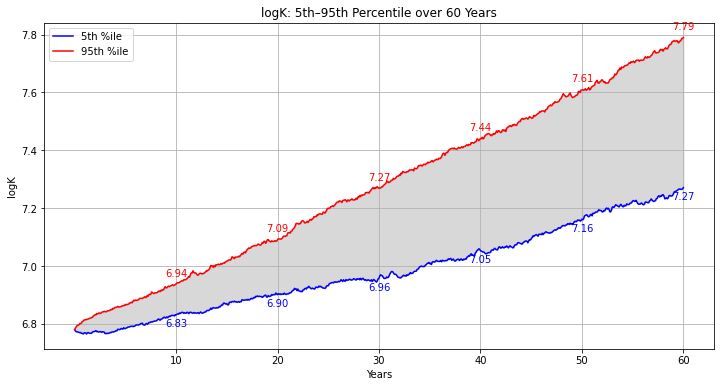

Processing variable: Z


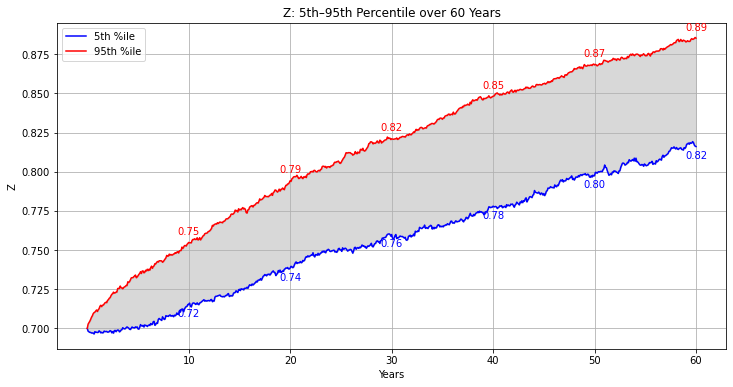

Processing variable: log_R


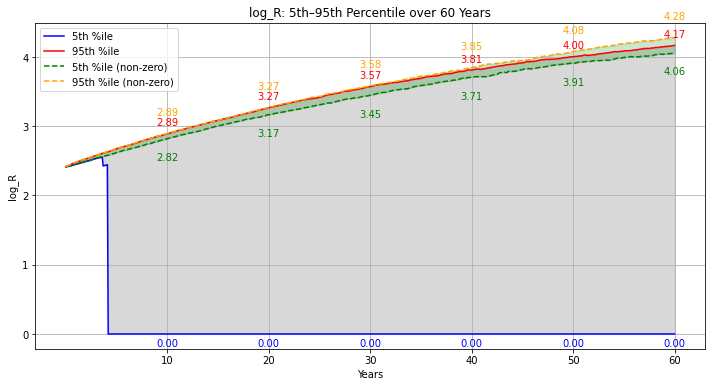

Processing variable: Y


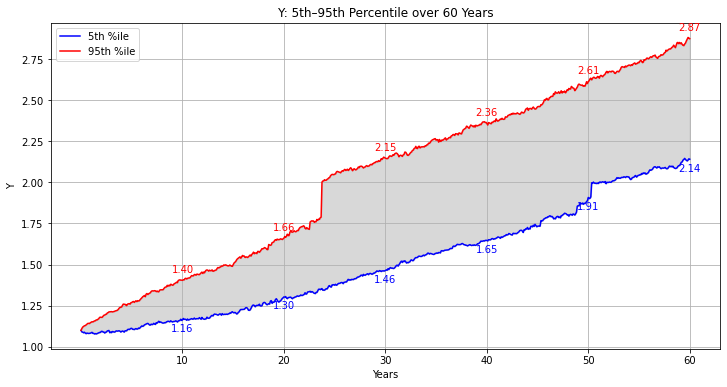

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Folder where the simulation results are stored.
data_folder = '/project/lhansen/Cap_NN_oldVersion/November_version_NewParameters/Simulation/paths#100'

variables = {
    'logK':   'logK_sim',
    'Z':      'R_array',
    'log_R':  'log_I_g_array',   # here log_R is actually your log_I_g_array
    'Y':      'Y_array'
}

def load_and_concatenate(folder, prefix):
    files = [os.path.join(folder, f) 
             for f in os.listdir(folder) 
             if f.startswith(prefix) and f.endswith('.npy')]
    if not files:
        print(f"No files found for prefix '{prefix}' in folder '{folder}'")
        return None
    files.sort()
    data_list = [np.load(f) for f in files]
    return np.concatenate(data_list, axis=0)

for var_label, prefix in variables.items():
    print(f"Processing variable: {var_label}")
    data = load_and_concatenate(data_folder, prefix)
    if data is None:
        continue

    # number of months
    n_months = data.shape[1]
    # convert month indices to years
    time_months = np.arange(n_months)
    time_years  = time_months / 12.0

    # compute 5th & 95th percentiles including zeros
    lower = np.percentile(data, 5, axis=0)
    upper = np.percentile(data, 95, axis=0)

    # set up the figure
    plt.figure(figsize=(12, 6))
    plt.plot(time_years, lower, label='5th %ile', color='blue')
    plt.plot(time_years, upper, label='95th %ile', color='red')
    plt.fill_between(time_years, lower, upper, color='gray', alpha=0.3)

    # decide decade ticks up to max full decade in your sim
    max_year = np.floor(time_years[-1])
    decade_ticks = np.arange(10, max_year+1, 10)
    plt.xticks(decade_ticks)
    plt.xlabel('Years')
    plt.ylabel(var_label)
    plt.title(f'{var_label}: 5th–95th Percentile over {max_year:.0f} Years')

    # annotate the two lines at each decade
    for year in decade_ticks:
        idx = int(year * 12)  # convert back to month index
        y_low = lower[idx]
        y_up  = upper[idx]
        plt.annotate(f"{y_low:.2f}", (year, y_low),
                     textcoords="offset points", xytext=(0,-12),
                     ha='center', color='blue')
        plt.annotate(f"{y_up:.2f}",  (year, y_up),
                     textcoords="offset points", xytext=(0,  8),
                     ha='center', color='red')

    # --- extra for log_I_g_array: exclude zeros and re‑plot percentiles ---
    if prefix == 'log_I_g_array':
        # compute percentiles at each t over non‑zero paths
        lower_nz = np.empty(n_months)
        upper_nz = np.empty(n_months)
        for t in range(n_months):
            col = data[:, t]
            nz  = col[col != 0]
            if nz.size:
                lower_nz[t] = np.percentile(nz, 5)
                upper_nz[t] = np.percentile(nz, 95)
            else:
                lower_nz[t] = np.nan
                upper_nz[t] = np.nan

        plt.plot(time_years, lower_nz, '--', label='5th %ile (non‑zero)', color='green')
        plt.plot(time_years, upper_nz, '--', label='95th %ile (non‑zero)', color='orange')
        plt.fill_between(time_years, lower_nz, upper_nz, color='green', alpha=0.2)

        # annotate the non‑zero lines
        for year in decade_ticks:
            idx = int(year * 12)
            y_lz = lower_nz[idx]
            y_uz = upper_nz[idx]
            if not np.isnan(y_lz):
                plt.annotate(f"{y_lz:.2f}", (year, y_lz),
                             textcoords="offset points", xytext=(0,-22),
                             ha='center', color='green')
            if not np.isnan(y_uz):
                plt.annotate(f"{y_uz:.2f}", (year, y_uz),
                             textcoords="offset points", xytext=(0, 18),
                             ha='center', color='orange')

    plt.legend(loc='best')
    plt.grid(True)
    plt.show()
